In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import h5py 
import os
import pandas as pd
import matplotlib.colors as mcolors


In [2]:
dirpath = '/Users/kimchm/Documents/KimNiNature2024/MatConverted2Python/' 
# sessName = 'BAYLORJH035_FOV1_2021_12_09_2022_02_15.npy'
# sessName = 'BAYLORJH035_FOV1_2022_02_24_2022_05_23.npy'
# filepath = dirpath + sessName

In [66]:
metadata = pd.read_csv(dirpath + 'EDF10d_info_2026_01_16.csv')
CDdotprod_python = pd.read_csv('CDdotprod_python_deconvolved.txt')
# Compare CD dot products of CK and JH
metadata['Merged_ID'] = (
    metadata['Mouse ID'].str.strip("'") + '_' + 
    metadata['FOV'].str.strip("'") + '_' + 
    metadata['Session1'].str.strip("'").str.replace("-", "_") + '_' + 
    metadata['Session2'].str.strip("'").str.replace("-", "_")
)
cols = ['Merged_ID'] + [c for c in metadata.columns if c != 'Merged_ID']
metadata = metadata[cols]
metadata = metadata.sort_values(by='Merged_ID')
metadata = metadata.reset_index(drop=True)
filtered_CDdotprod_python = CDdotprod_python[CDdotprod_python['ID'].isin(metadata['Merged_ID'])].reset_index(drop=True)
# sort by CD dot product
colname_CDdotproduct = 'CDdotproduct'
CDdotproduct = filtered_CDdotprod_python[colname_CDdotproduct]
sorted_indices_by_CDdotproduct = np.argsort(CDdotproduct)
#--- sorted by CD dot product ---#
nfile = len(filtered_CDdotprod_python)
file_ix = 0
fidx = sorted_indices_by_CDdotproduct[file_ix]
filename = filtered_CDdotprod_python['ID'][fidx]
filepath = dirpath + filename + '.npy'
data = np.load(filepath, allow_pickle=True)



In [67]:
# data = np.load(filepath, allow_pickle=True)
# data.keys()

In [68]:
opto_sess1 = data['deconvolved'][0]
opto_sess2 = data['deconvolved'][1]

# opto_sess1 = data['dFF0'][0]
# opto_sess2 = data['dFF0'][1]

In [69]:
tsample   = 1.57
tdelay    = 2.87
tresponse = 4.17
dt        = 1/6
ntimestep = 47
tvec      = dt * np.arange(ntimestep)

tix_delay    = np.where(tvec > tdelay)[0][0]
tix_response = np.where(tvec > tresponse)[0][0]
print('tix delay: ', tix_delay, ', tix response: ', tix_response)

tix delay:  18 , tix response:  26


In [70]:
ncat, ncell = opto_sess1.shape
lickright = 0
lickleft  = 1

In [71]:
# concatenate all trials into one array
ntrials_1R = opto_sess1[lickright,0].shape[1]
ntrials_1L = opto_sess1[lickleft,0].shape[1]
ntrials_2R = opto_sess2[lickright,0].shape[1]
ntrials_2L = opto_sess2[lickleft,0].shape[1]
opto_1R_alltrials = np.zeros((ncell,ntimestep,ntrials_1R))
opto_1L_alltrials = np.zeros((ncell,ntimestep,ntrials_1L))
opto_2R_alltrials = np.zeros((ncell,ntimestep,ntrials_2R))
opto_2L_alltrials = np.zeros((ncell,ntimestep,ntrials_2L))
for cell in range(ncell):
    opto_1R_alltrials[cell] = opto_sess1[lickright,cell]
    opto_1L_alltrials[cell] = opto_sess1[lickleft,cell]
    opto_2R_alltrials[cell] = opto_sess2[lickright,cell]
    opto_2L_alltrials[cell] = opto_sess2[lickleft,cell]


In [72]:
print('number of trials: ', '1R', ntrials_1R, ', 1L', ntrials_1L, ', 2R', ntrials_2R, ', 2L', ntrials_2L)

number of trials:  1R 94 , 1L 109 , 2R 101 , 2L 104


In [73]:
# use only half of the trials to construct the CD
frac_train = 0.5
ntrain_trials_1R = int(ntrials_1R*frac_train)
ntrain_trials_1L = int(ntrials_1L*frac_train)
ntrain_trials_2R = int(ntrials_2R*frac_train)
ntrain_trials_2L = int(ntrials_2L*frac_train)
opto_1R = np.zeros((ncell,ntimestep))
opto_1L = np.zeros((ncell,ntimestep))
opto_2R = np.zeros((ncell,ntimestep))
opto_2L = np.zeros((ncell,ntimestep))
for cell in range(ncell):
    opto_1R[cell] = np.mean(opto_1R_alltrials[cell,:,:ntrain_trials_1R],axis=1)
    opto_1L[cell] = np.mean(opto_1L_alltrials[cell,:,:ntrain_trials_1L],axis=1)
    opto_2R[cell] = np.mean(opto_2R_alltrials[cell,:,:ntrain_trials_2R],axis=1)
    opto_2L[cell] = np.mean(opto_2L_alltrials[cell,:,:ntrain_trials_2L],axis=1)    
CD_sess1 = opto_1R - opto_1L
CD_sess2 = opto_2R - opto_2L
MR_sess1 = opto_1R + opto_1L
MR_sess2 = opto_2R + opto_2L

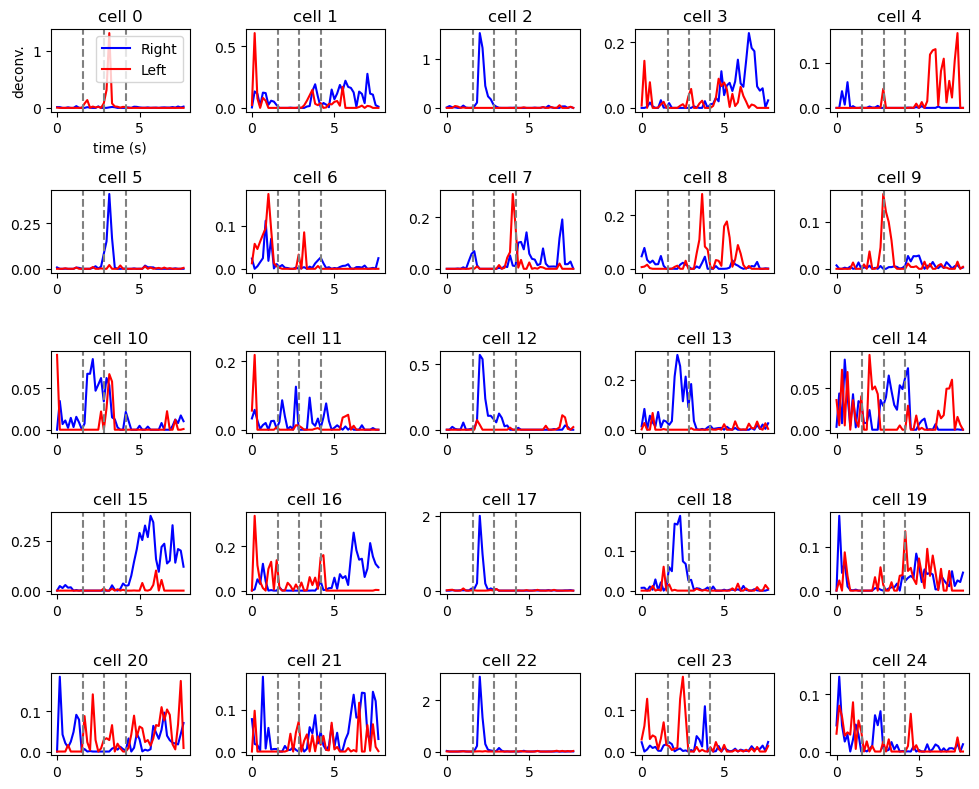

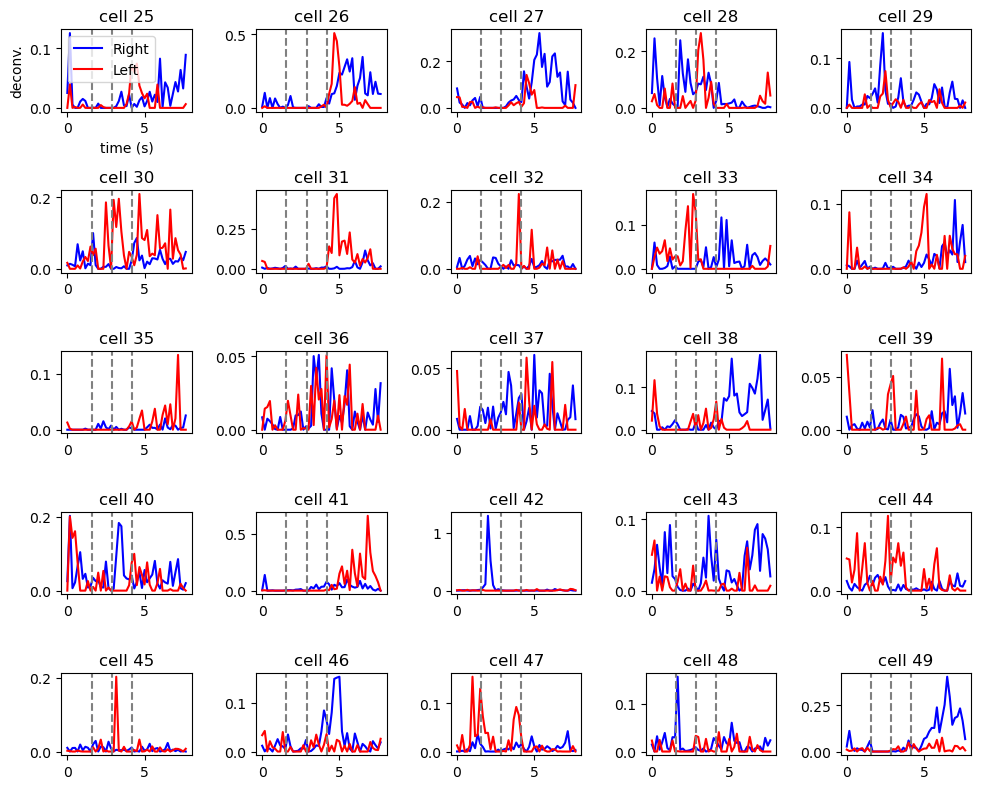

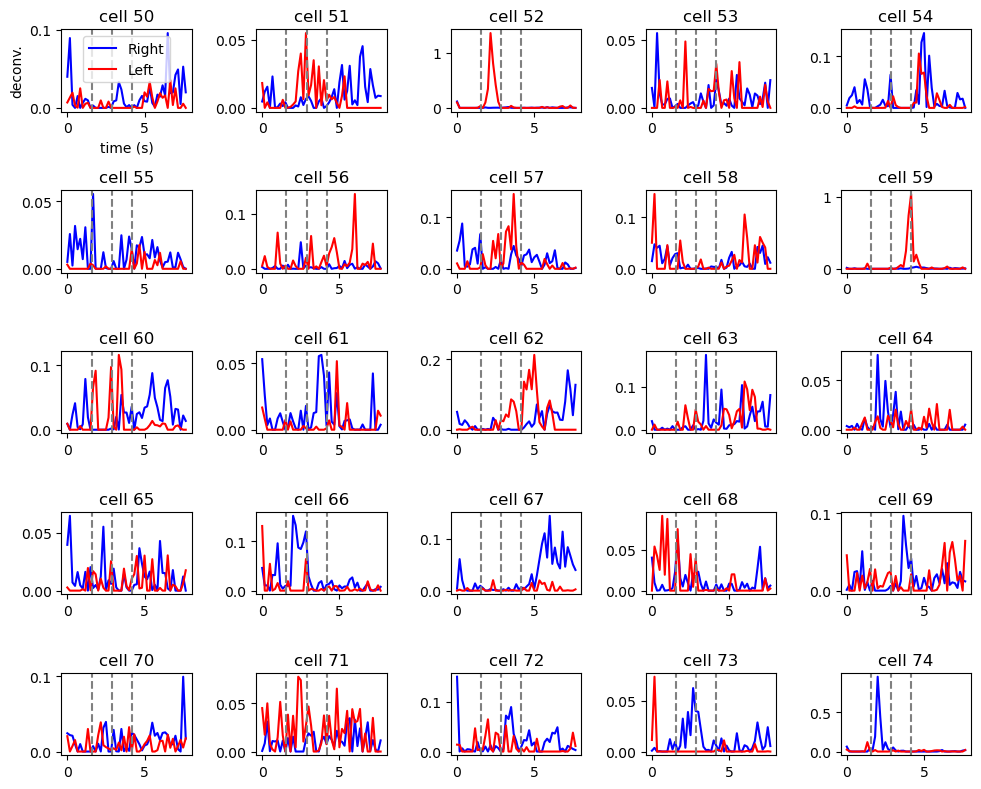

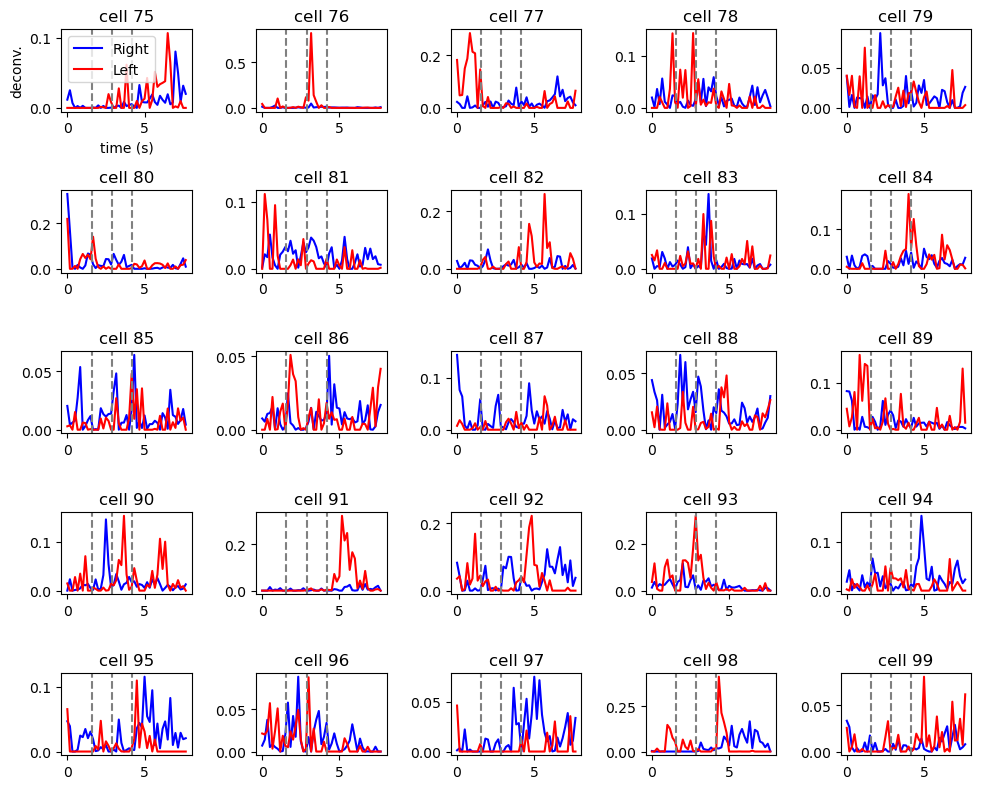

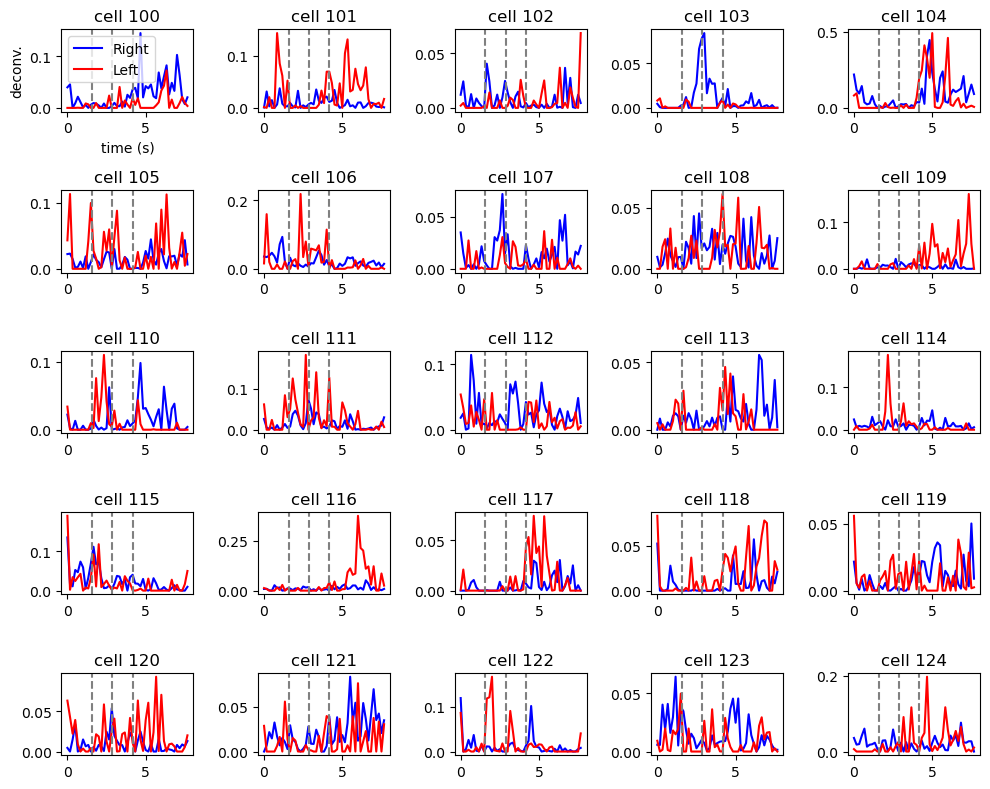

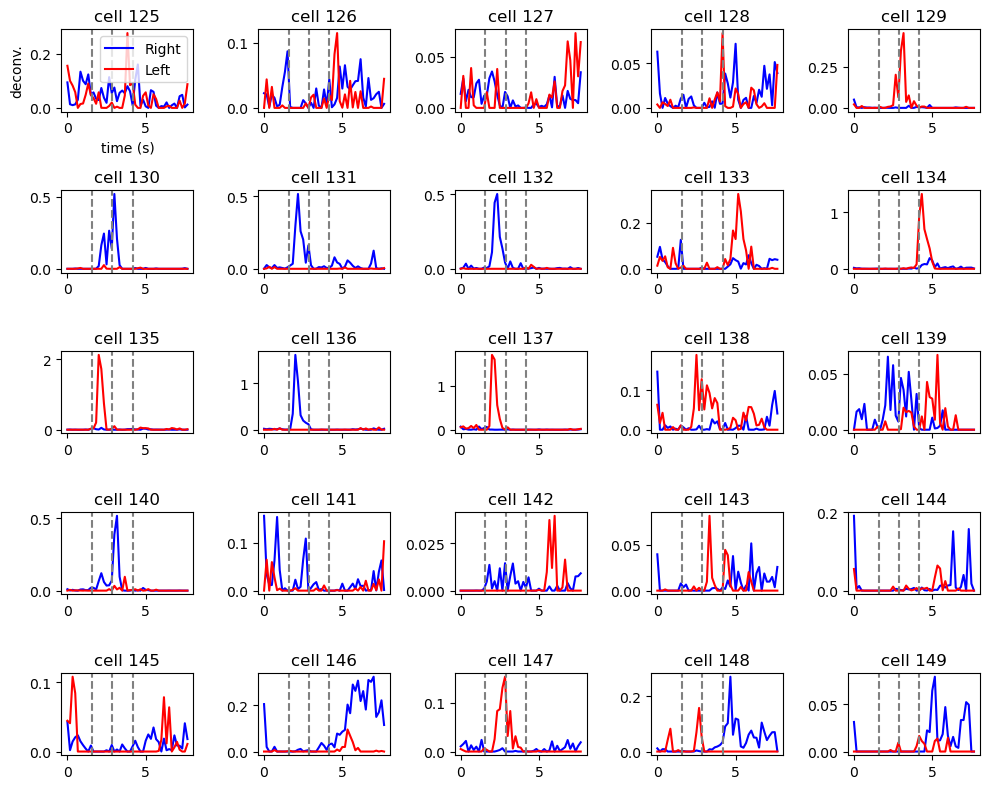

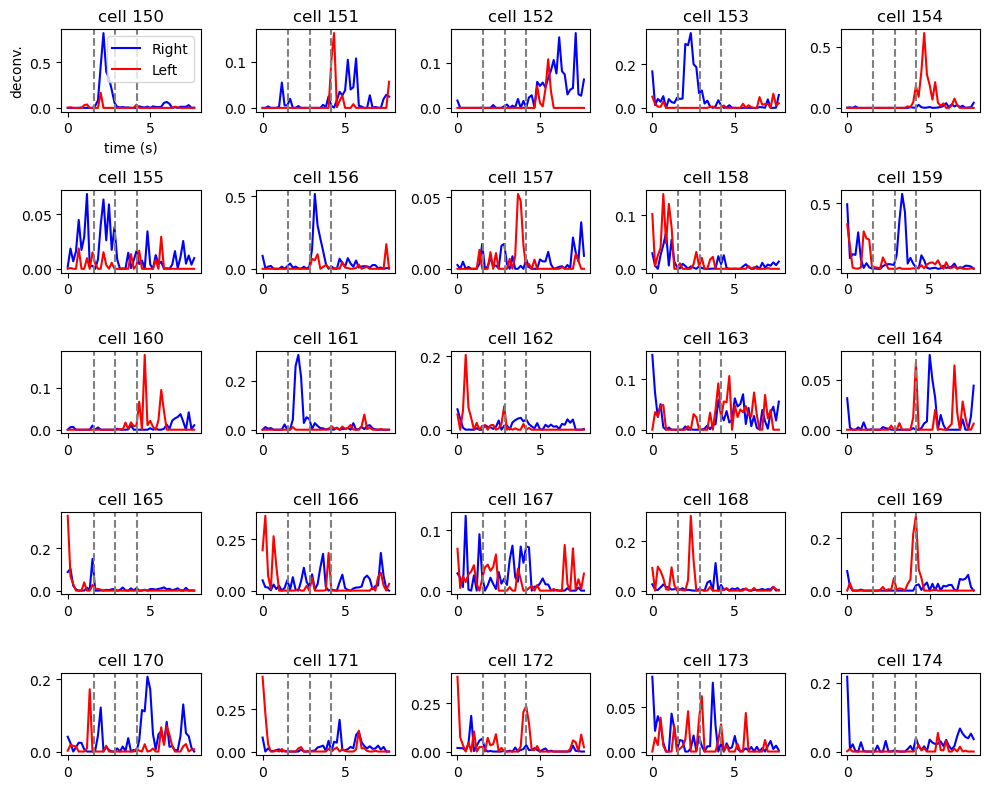

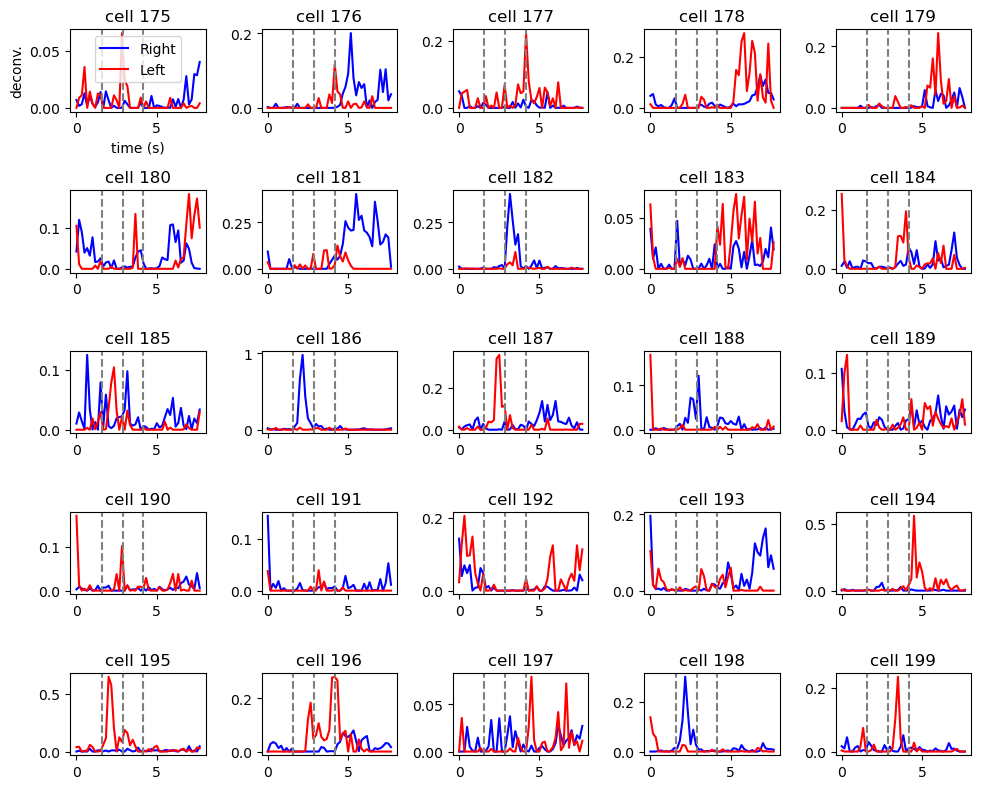

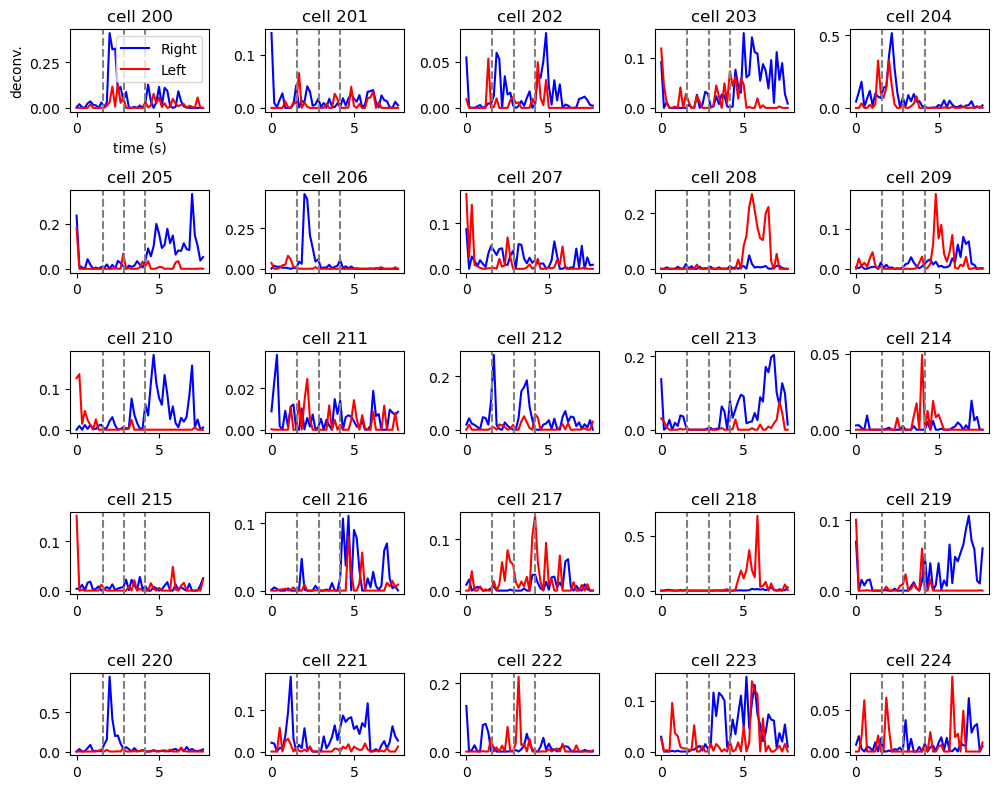

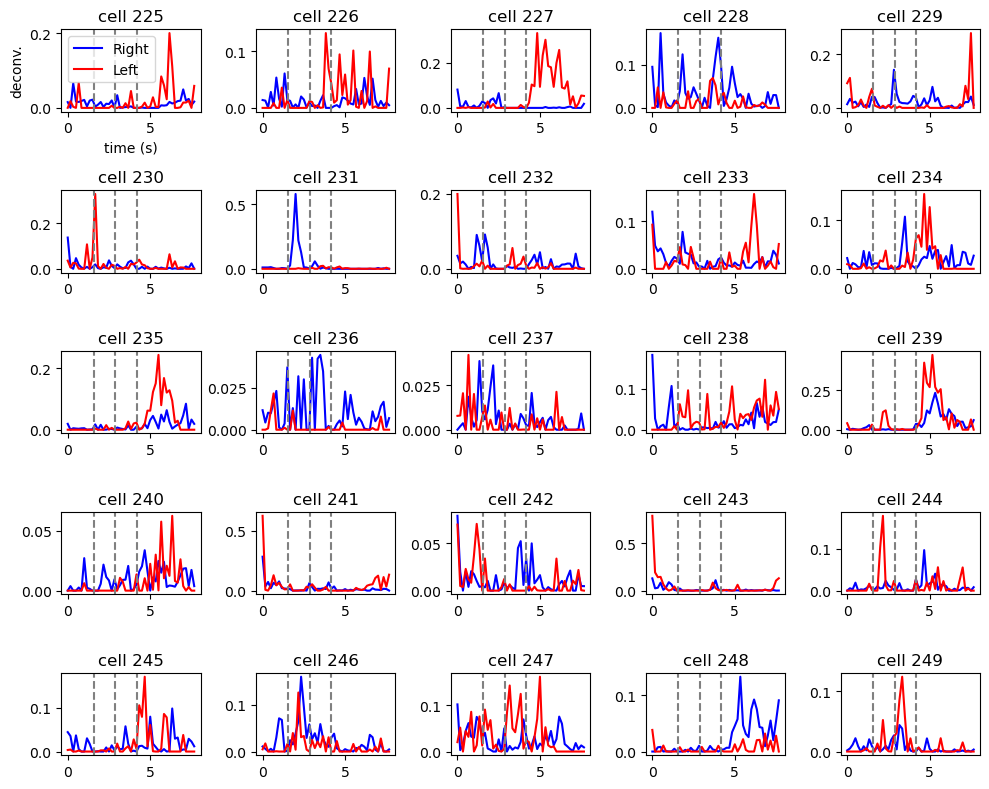

In [218]:
for j_grp in range(10):
    
    ngrp = 25 * j_grp
    
    plt.figure(figsize=(10,8))
    for i, cell in enumerate(range(25)):
        plt.subplot(5,5,i+1)
        cell = i + ngrp
        plt.plot(tvec, opto_1R[cell], c='b', label='Right')
        plt.plot(tvec, opto_1L[cell], c='r', label='Left')
        # plt.plot(tvec, MR_sess1[cell]/2, c='gray')
        plt.axvline(tsample, color='gray', linestyle='--')
        plt.axvline(tdelay, color='gray', linestyle='--')
        plt.axvline(tresponse, color='gray', linestyle='--')
        plt.title('cell ' + str(cell))
        if i ==0 :
            plt.xlabel('time (s)')
            plt.ylabel('deconv.')
            plt.legend()
    plt.tight_layout()
    plt.savefig('figure/psth_group'+str(j_grp)+'.pdf')


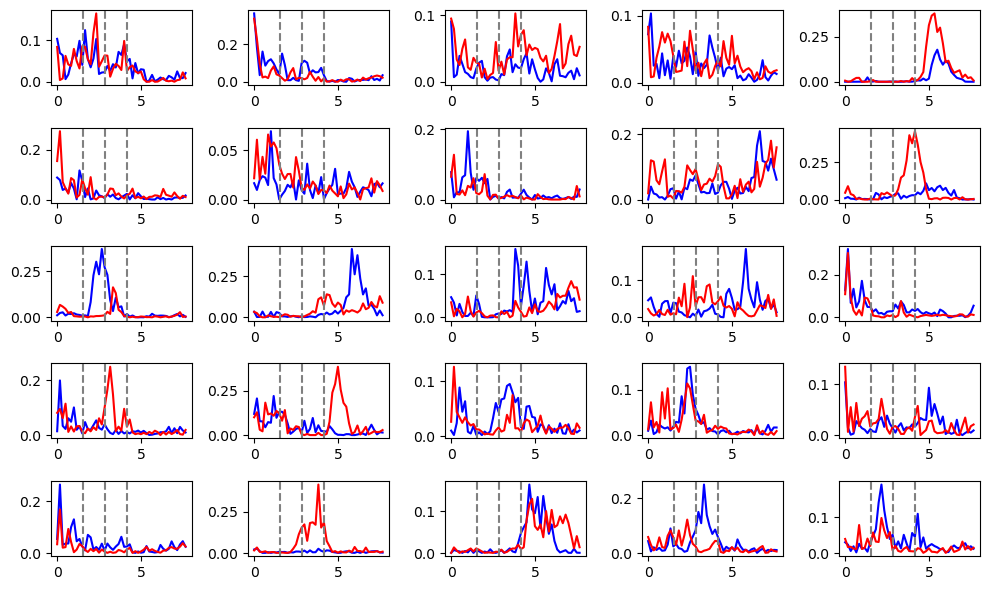

In [74]:
plt.figure(figsize=(10,6))
for i, cell in enumerate(range(25)):
    plt.subplot(5,5,i+1)
    cell = i + 50
    plt.plot(tvec, opto_2R[cell], c='b')
    plt.plot(tvec, opto_2L[cell], c='r')
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')
plt.tight_layout()


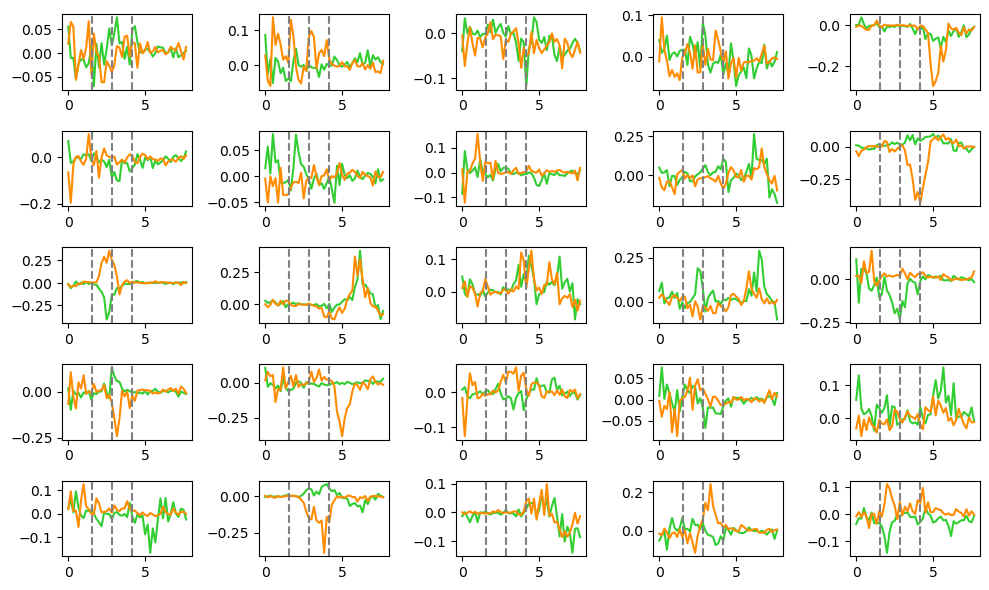

In [75]:
plt.figure(figsize=(10,6))
for i, cell in enumerate(range(25)):
    plt.subplot(5,5,i+1)
    cell = i + 50
    plt.plot(tvec, CD_sess1[cell], c='limegreen')
    plt.plot(tvec, CD_sess2[cell], c='darkorange')
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')
plt.tight_layout()


In [76]:
CD_sess1_population = np.mean(CD_sess1[:,tix_response-4:tix_response], axis=1)
CD_sess2_population = np.mean(CD_sess2[:,tix_response-4:tix_response], axis=1)
CD_dotproduct       = np.inner(CD_sess1_population, CD_sess2_population) / (np.linalg.norm(CD_sess1_population) * np.linalg.norm(CD_sess2_population))
print('CD dot product: ', CD_dotproduct)


CD dot product:  -0.41959291134643306


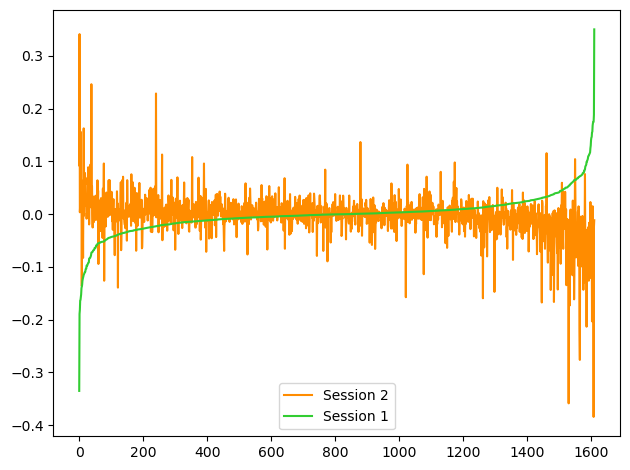

In [77]:
cell_sorted_CDdelay_sess1 = np.argsort(CD_sess1_population)
plt.figure()
# plt.plot(CD_sess1_population, CD_sess2_population, marker='.', linestyle='')
plt.plot(CD_sess2_population[cell_sorted_CDdelay_sess1], c='darkorange', label='Session 2')
plt.plot(CD_sess1_population[cell_sorted_CDdelay_sess1], c='limegreen', label='Session 1')
plt.legend()
plt.tight_layout()

In [78]:
cos_sim = np.zeros(ncell)
for ci in range(ncell):
    CD1 = CD_sess1[ci]
    CD2 = CD_sess2[ci]
    cos_sim[ci] = np.dot(CD1,CD2) / np.linalg.norm(CD1) / np.linalg.norm(CD2)

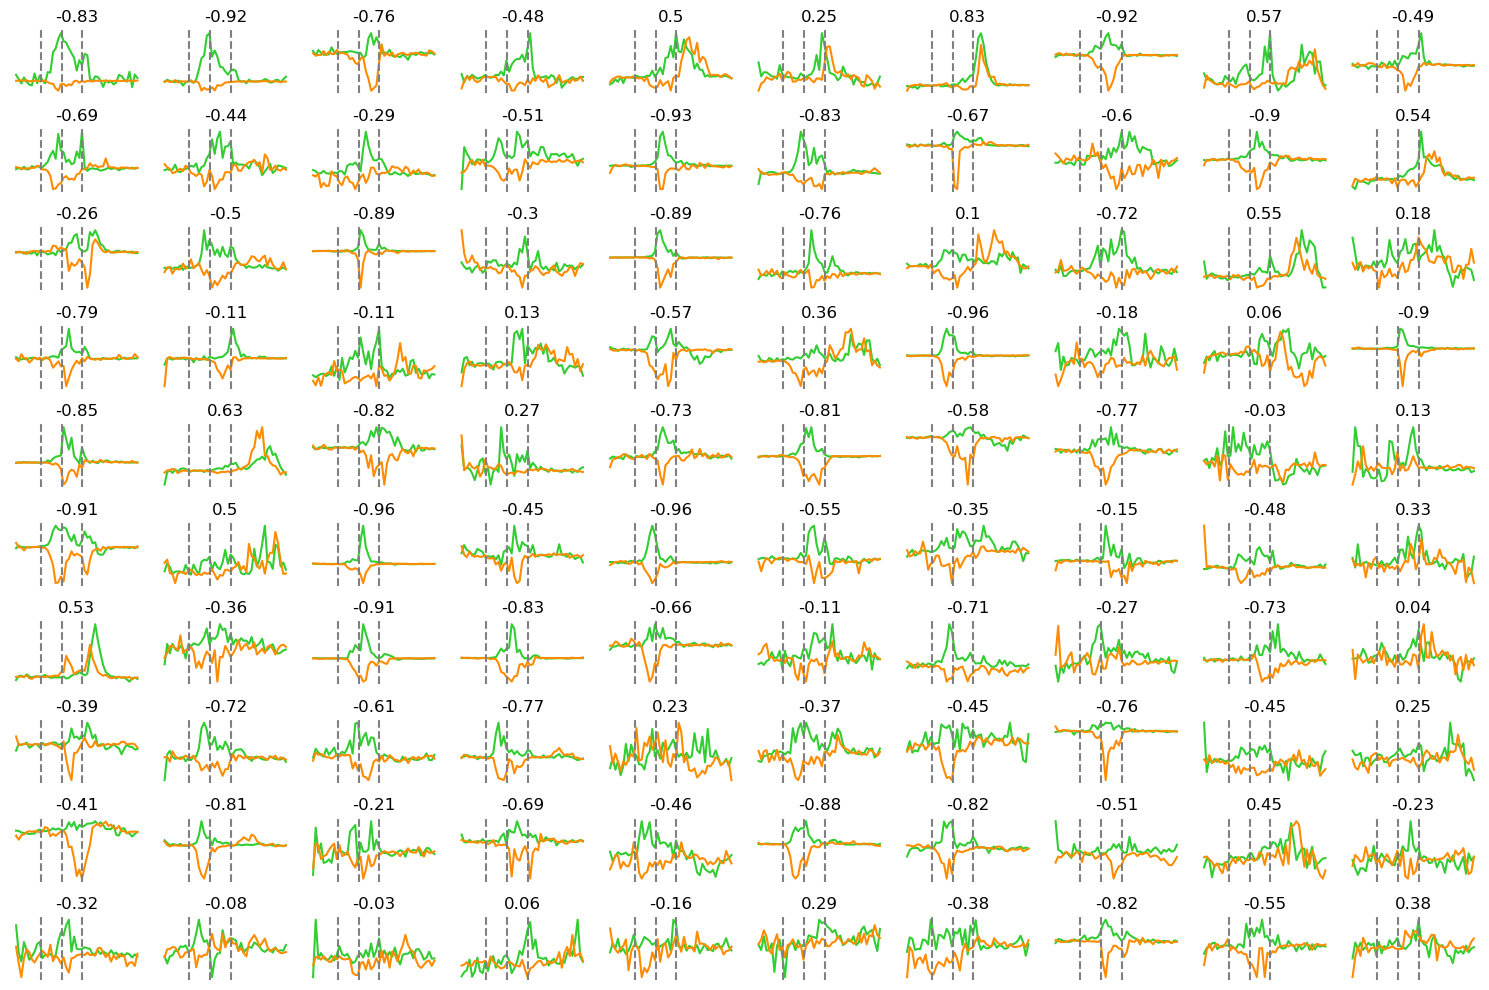

In [80]:
plt.figure(figsize=(15,10))
for i in range(100):
    plt.subplot(10,10,i+1)
    cell = cell_sorted_CDdelay_sess1[-i-1]
    plt.plot(tvec, CD_sess1[cell], c='limegreen')
    plt.plot(tvec, CD_sess2[cell], c='darkorange')
    # plt.plot(tvec, CD_sess2[cell] - CD_sess1[cell], c='k')    
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')
    plt.axis('off')
    plt.title(str(np.round(cos_sim[cell],decimals=2)), fontsize=12)
plt.tight_layout()


(array([147.,  84., 135., 203., 302., 324., 222., 116.,  49.,  29.]),
 array([-0.99797317, -0.8092705 , -0.62056783, -0.43186515, -0.24316248,
        -0.05445981,  0.13424287,  0.32294554,  0.51164821,  0.70035089,
         0.88905356]),
 [<matplotlib.patches.Polygon at 0x13788a9e0>])

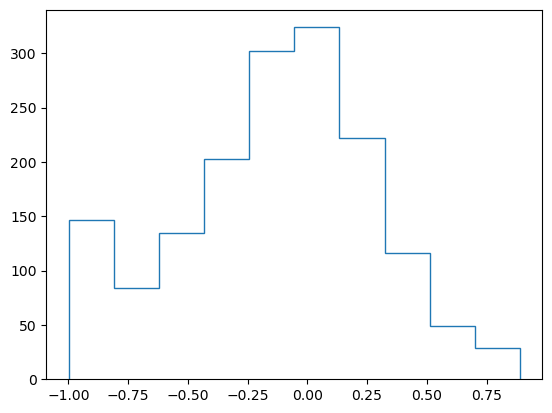

In [79]:
plt.figure()
plt.hist(cos_sim, histtype='step')

## Project population activity to CD

In [223]:
# project population activity to CD. Use only the test trials
opto_1R_testtrials = opto_1R_alltrials[:,:,ntrain_trials_1R:]
opto_1L_testtrials = opto_1L_alltrials[:,:,ntrain_trials_1L:]
opto_2R_testtrials = opto_2R_alltrials[:,:,ntrain_trials_2R:]
opto_2L_testtrials = opto_2L_alltrials[:,:,ntrain_trials_2L:]

proj_1R_CD1 = np.tensordot(CD_sess1_population, opto_1R_testtrials, axes=(0,0))
proj_1L_CD1 = np.tensordot(CD_sess1_population, opto_1L_testtrials, axes=(0,0))
proj_2R_CD2 = np.tensordot(CD_sess2_population, opto_2R_testtrials, axes=(0,0))
proj_2L_CD2 = np.tensordot(CD_sess2_population, opto_2L_testtrials, axes=(0,0))

proj_1R_CD2 = np.tensordot(CD_sess2_population, opto_1R_testtrials, axes=(0,0))
proj_1L_CD2 = np.tensordot(CD_sess2_population, opto_1L_testtrials, axes=(0,0))
proj_2R_CD1 = np.tensordot(CD_sess1_population, opto_2R_testtrials, axes=(0,0))
proj_2L_CD1 = np.tensordot(CD_sess1_population, opto_2L_testtrials, axes=(0,0))

print(proj_1R_CD1.shape, proj_1L_CD1.shape, proj_2R_CD2.shape, proj_2L_CD2.shape)


(47, 26) (47, 12) (47, 48) (47, 43)


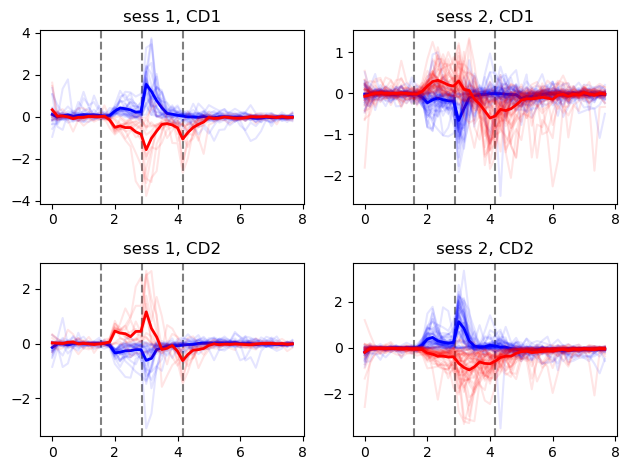

In [224]:
def plot_proj(tvec, proj_R, proj_L, ntest_trials_R, ntest_trials_L):
    plt.axvline(tsample, color='gray', linestyle='--')
    plt.axvline(tdelay, color='gray', linestyle='--')
    plt.axvline(tresponse, color='gray', linestyle='--')
    for trial in range(ntest_trials_R):
        plt.plot(tvec, proj_R[:,trial], c='b', alpha=0.1)
    plt.plot(tvec, np.mean(proj_R,axis=1), c='b', lw=2)
    for trial in range(ntest_trials_L):
        plt.plot(tvec, proj_L[:,trial], c='r', alpha=0.1)
    plt.plot(tvec, np.mean(proj_L,axis=1), c='r', lw=2)
    
ntest_trials_1R = ntrials_1R - ntrain_trials_1R
ntest_trials_1L = ntrials_1L - ntrain_trials_1L
ntest_trials_2R = ntrials_2R - ntrain_trials_2R
ntest_trials_2L = ntrials_2L - ntrain_trials_2L

plt.figure()
plt.subplot(2,2,1)
plt.title('sess 1, CD1')
proj_R = proj_1R_CD1
proj_L = proj_1L_CD1
plot_proj(tvec, proj_R, proj_L, ntest_trials_1R, ntest_trials_1L)

plt.subplot(2,2,2)
plt.title('sess 2, CD1')
proj_R = proj_2R_CD1
proj_L = proj_2L_CD1
plot_proj(tvec, proj_R, proj_L, ntest_trials_2R, ntest_trials_2L)

plt.subplot(2,2,3)
plt.title('sess 1, CD2')
proj_R = proj_1R_CD2
proj_L = proj_1L_CD2
plot_proj(tvec, proj_R, proj_L, ntest_trials_1R, ntest_trials_1L)

plt.subplot(2,2,4)
plt.title('sess 2, CD2')
proj_R = proj_2R_CD2
proj_L = proj_2L_CD2
plot_proj(tvec, proj_R, proj_L, ntest_trials_2R, ntest_trials_2L)

plt.tight_layout()


## Compare my and jh CD dot producdts

In [262]:
metadata = pd.read_csv(dirpath + 'EDF10d_info_2026_01_16.csv')
CDdotprod_python = pd.read_csv('CDdotprod_python_deconvolved.txt')

In [263]:
metadata['Merged_ID'] = (
    metadata['Mouse ID'].str.strip("'") + '_' + 
    metadata['FOV'].str.strip("'") + '_' + 
    metadata['Session1'].str.strip("'").str.replace("-", "_") + '_' + 
    metadata['Session2'].str.strip("'").str.replace("-", "_")
)
cols = ['Merged_ID'] + [c for c in metadata.columns if c != 'Merged_ID']
metadata = metadata[cols]
metadata = metadata.sort_values(by='Merged_ID')
metadata = metadata.reset_index(drop=True)

In [264]:
filtered_CDdotprod_python = CDdotprod_python[CDdotprod_python['ID'].isin(metadata['Merged_ID'])].reset_index(drop=True)
filtered_CDdotprod_python.head()

,ID,CDdotproduct
0,BAYLORJH035_FOV1_2021_12_09_2022_02_15,-0.082322
1,BAYLORJH035_FOV1_2022_02_24_2022_05_23,-0.073478
2,BAYLORJH118_FOV1_2022_09_29_2022_10_26,0.566145
3,BAYLORJH118_FOV1_2022_10_26_2022_11_27,0.553590
4,BAYLORJH118_FOV2_2022_09_30_2022_10_27,0.022064


In [265]:
is_aligned = metadata['Merged_ID'].equals(filtered_CDdotprod_python['ID'])
print('is aligned: ', is_aligned)

is aligned:  True


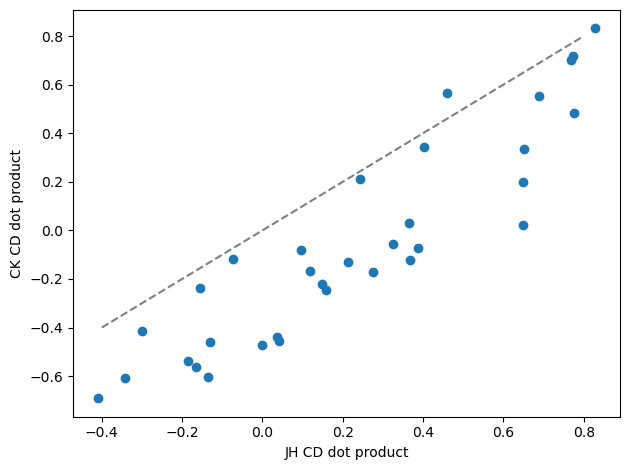

In [266]:
# filtered_CDdotprod_python.keys()
idline = np.arange(-0.4,0.8,0.1)
my_CDdotprod = filtered_CDdotprod_python['CDdotproduct']
jh_CDdotprod = metadata['CDdotproduct']
plt.figure()
plt.plot(idline, idline, color='gray', linestyle='--')
plt.scatter(jh_CDdotprod, my_CDdotprod)
plt.xlabel('JH CD dot product')
plt.ylabel('CK CD dot product')
plt.tight_layout()

### Sort the files by CD dot product

In [256]:

filtered_CDdotprod_sorted = filtered_CDdotprod_python.sort_values(by='CDdotproduct').reset_index(drop=True)
filtered_CDdotprod_sorted['ID'][0]

'BAYLORJH123_FOV1_2022_10_01_2022_11_07'

In [259]:
dirpath = '/Users/kimchm/Documents/KimNiNature2024/MatConverted2Python/' 
sessName = filtered_CDdotprod_sorted['ID'][0] + '.npy'
filepath = dirpath + sessName
_data = np.load(filepath, allow_pickle=True)


In [267]:
len(filtered_CDdotprod_sorted)

33

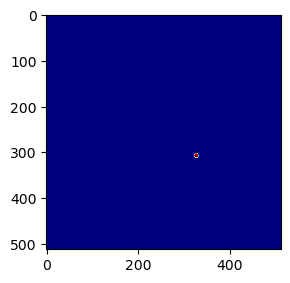

In [260]:
_sf = _data['spatial_footprints']
cell = 1
cix = _sf[:,:,cell]>0
sf_CD = np.zeros((512,512,ncell))
sf_CD[cix,cell] = sf_CD[cix,cell] + 1
plt.figure(figsize=(3,3))
plt.imshow(sf_CD[:,:,cell], cmap='jet')
plt.tight_layout()


In [261]:
_sf.shape

(512, 512, 1611)

# Spatial footprint

In [230]:
sf = data['spatial_footprints']

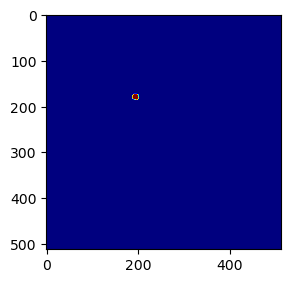

In [231]:
cell = 1
cix = sf[:,:,cell]>0
sf_CD = np.zeros((512,512,ncell))
sf_CD[cix,cell] = sf_CD[cix,cell] + 1
plt.figure(figsize=(3,3))
plt.imshow(sf_CD[:,:,cell], cmap='jet')
# plt.xlim([100,200])
# plt.ylim([100,200])
plt.tight_layout()

In [232]:
sf_sess1_CD = np.zeros((512,512,ncell))
sf_sess2_CD = np.zeros((512,512,ncell))
sf_sess1_SI = np.zeros((512,512,ncell))
sf_sess2_SI = np.zeros((512,512,ncell))
for cell in range(ncell):
    cix = sf[:,:,cell] > 0
    sf_sess1_CD[cix,cell] += 1
    sf_sess2_CD[cix,cell] += 1
    sf_sess1_CD[cix,cell] *= CD_sess1_population[cell]
    sf_sess2_CD[cix,cell] *= CD_sess2_population[cell]
    
    # sf_sess1_SI[cix,cell] += 1
    # sf_sess2_SI[cix,cell] += 1
    # sf_sess1_SI[cix,cell] *= SI_sess1_population[cell]
    # sf_sess2_SI[cix,cell] *= SI_sess2_population[cell]    

In [270]:
print(np.sum(CD_sess1_population>0))
print(np.sum(CD_sess1_population<0))
print(np.sum(CD_sess2_population>0))
print(np.sum(CD_sess2_population<0))

513
494
477
532


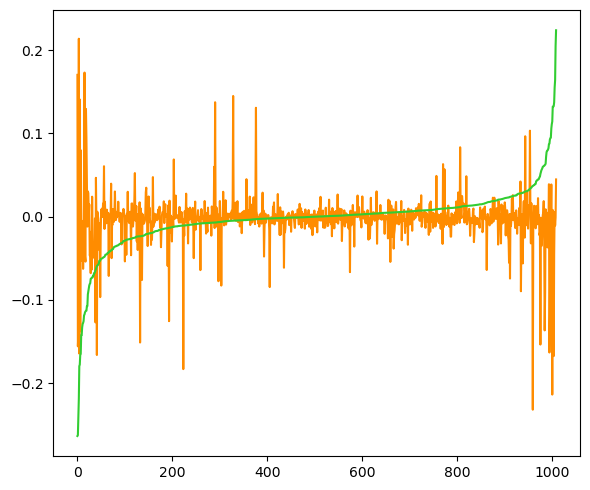

In [276]:
neuron_sorted_by_CD_sess1 = np.argsort(CD_sess1_population)
plt.figure(figsize=(6,5))
plt.plot(CD_sess2_population[neuron_sorted_by_CD_sess1], c='darkorange')
plt.plot(CD_sess1_population[neuron_sorted_by_CD_sess1], c='limegreen')
plt.tight_layout()


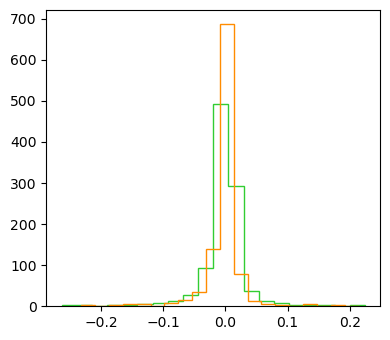

In [233]:
plt.figure(figsize=(4,3.5))
# plt.subplot(121)
plt.hist(CD_sess1_population, bins=20, histtype='step', color='limegreen')
plt.hist(CD_sess2_population, bins=20, histtype='step', color='darkorange')
# plt.subplot(122)
# plt.hist(SI_sess1_population, bins=50, histtype='step', color='limegreen', range=(-1,1))
# plt.hist(SI_sess2_population, bins=50, histtype='step', color='darkorange', range=(-1,1))
plt.tight_layout()

In [235]:
ncell_selected = int(ncell * 0.1)
sorted_cells_sess1 = np.argsort(CD_sess1_population)
sorted_cells_sess2 = np.argsort(CD_sess2_population)
top_cells_sess1_lickright = sorted_cells_sess1[-ncell_selected:]
top_cells_sess2_lickright = sorted_cells_sess2[-ncell_selected:]
top_cells_sess1_lickleft  = sorted_cells_sess1[:ncell_selected]
top_cells_sess2_lickleft  = sorted_cells_sess2[:ncell_selected]
sf_sess1_CD_top_lickright = sf_sess1_CD[:,:,top_cells_sess1_lickright]
sf_sess2_CD_top_lickright = sf_sess2_CD[:,:,top_cells_sess2_lickright]
sf_sess1_CD_top_lickleft  = sf_sess1_CD[:,:,top_cells_sess1_lickleft]
sf_sess2_CD_top_lickleft  = sf_sess2_CD[:,:,top_cells_sess2_lickleft]


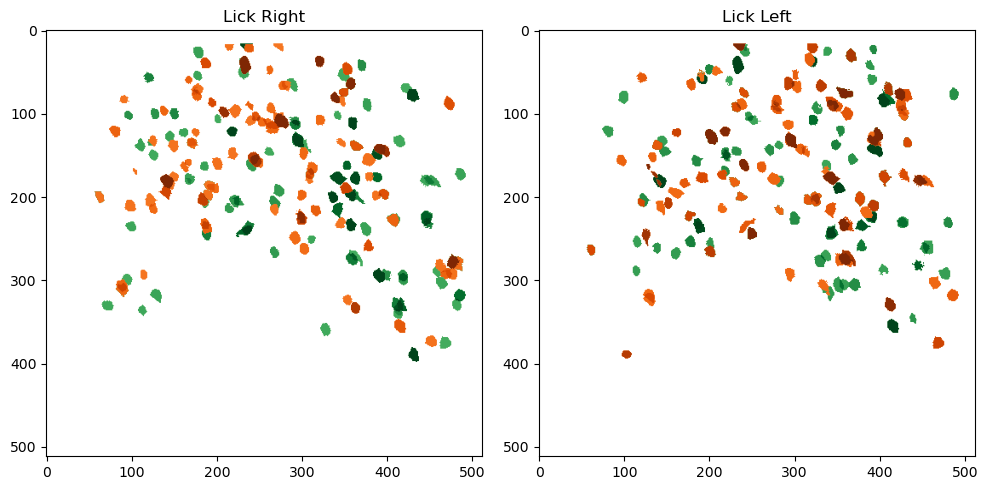

In [ ]:

sf_sess1_CD_topsum_lickright = np.sum(sf_sess1_CD_top_lickright, axis=2)
sf_sess2_CD_topsum_lickright = np.sum(sf_sess2_CD_top_lickright, axis=2)
sf_sess1_CD_topsum_lickleft  = -np.sum(sf_sess1_CD_top_lickleft, axis=2)
sf_sess2_CD_topsum_lickleft  = -np.sum(sf_sess2_CD_top_lickleft, axis=2)

vlim = 0.1
vmin, vmax = -vlim, vlim
norm  = mcolors.Normalize(vmin=vmin,vmax=vmax)
cmap1 = plt.get_cmap('Greens')
cmap2 = plt.get_cmap('Oranges')
plot_sf_sess1_lickright = cmap1(norm(sf_sess1_CD_topsum_lickright))
plot_sf_sess2_lickright = cmap2(norm(sf_sess2_CD_topsum_lickright))
plot_sf_sess1_lickright[sf_sess1_CD_topsum_lickright==0, 3] = 0
plot_sf_sess2_lickright[sf_sess2_CD_topsum_lickright==0, 3] = 0

plot_sf_sess1_lickleft = cmap1(norm(sf_sess1_CD_topsum_lickleft))
plot_sf_sess2_lickleft = cmap2(norm(sf_sess2_CD_topsum_lickleft))
plot_sf_sess1_lickleft[sf_sess1_CD_topsum_lickleft==0, 3] = 0
plot_sf_sess2_lickleft[sf_sess2_CD_topsum_lickleft==0, 3] = 0


plt.figure(figsize=(10,5))
plt.subplot(121)
plt.imshow(plot_sf_sess1_lickright, vmin=-vlim, vmax=vlim, aspect='auto')
plt.imshow(plot_sf_sess2_lickright, vmin=-vlim, vmax=vlim, aspect='auto')
# plt.colorbar()
plt.title('Lick Right')
plt.subplot(122)
plt.imshow(plot_sf_sess1_lickleft, vmin=-vlim, vmax=vlim, aspect='auto')
plt.imshow(plot_sf_sess2_lickleft, vmin=-vlim, vmax=vlim, aspect='auto')
plt.title('Lick Left')
plt.tight_layout()

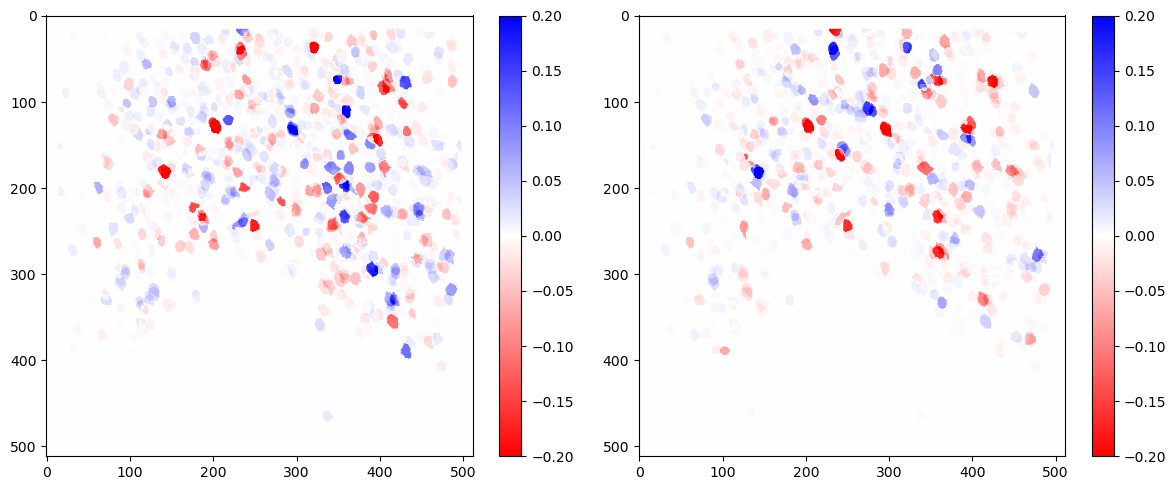

In [237]:
sf_sess1_CD_sum = np.sum(sf_sess1_CD, axis=2)
sf_sess2_CD_sum = np.sum(sf_sess2_CD, axis=2)
vlim = 0.2
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.imshow(sf_sess1_CD_sum, cmap='bwr_r', vmin=-vlim, vmax=vlim, aspect='auto')
plt.colorbar()
plt.subplot(122)
plt.imshow(sf_sess2_CD_sum, cmap='bwr_r', vmin=-vlim, vmax=vlim, aspect='auto')
plt.colorbar()
plt.tight_layout()

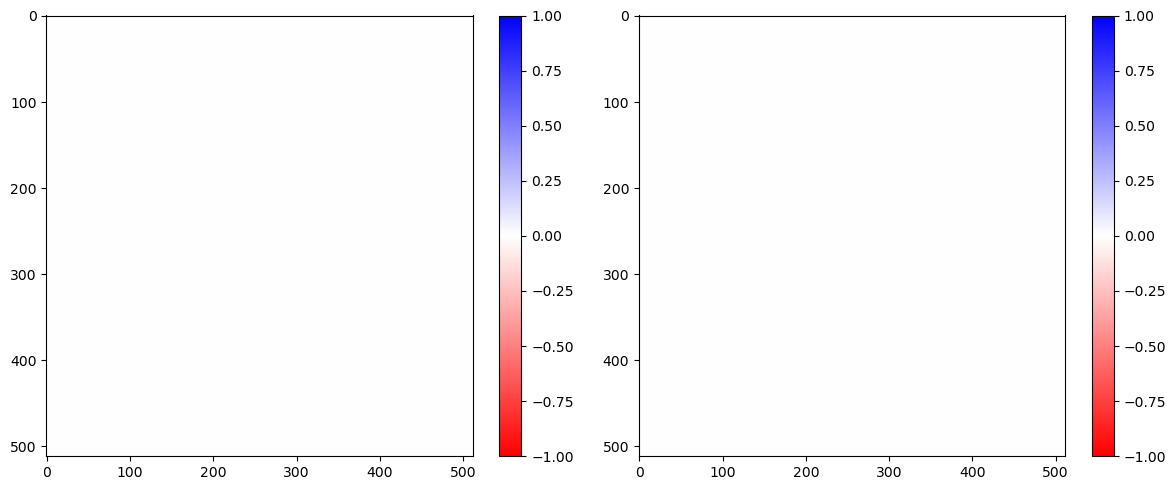

In [238]:
sf_sess1_SI_sum = np.sum(sf_sess1_SI, axis=2)
sf_sess2_SI_sum = np.sum(sf_sess2_SI, axis=2)
vlim = 1
plt.figure(figsize=(12,5))
plt.subplot(121)
plt.imshow(sf_sess1_SI_sum, cmap='bwr_r', vmin=-vlim, vmax=vlim, aspect='auto')
plt.colorbar()
plt.subplot(122)
plt.imshow(sf_sess2_SI_sum, cmap='bwr_r', vmin=-vlim, vmax=vlim, aspect='auto')
plt.colorbar()
plt.tight_layout()

In [239]:
sf_sess1_SI_topsum_lickright[0,0]==0

True